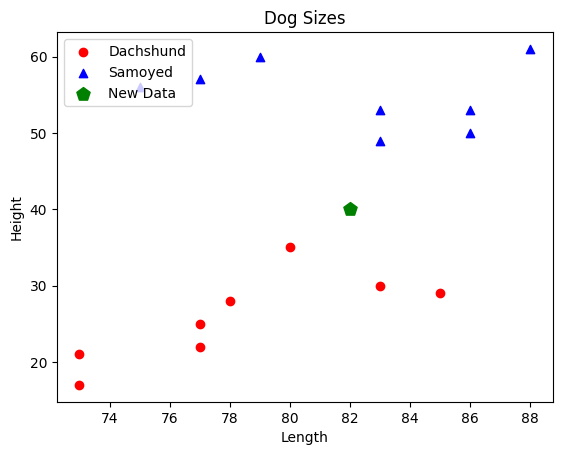

In [5]:
import matplotlib.pyplot as plt
import numpy as np

dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_hight = [56, 57, 50, 53, 60, 53, 49, 61]

newdata_length = [82]
newdata_height = [40]

plt.scatter(dach_length, dach_height, c='red', label='Dachshund')
plt.scatter(samo_length, samo_hight, c='blue', marker='^', label='Samoyed')
plt.scatter(newdata_length, newdata_height, c='green', marker='p', s=100, label='New Data')
plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Dog Sizes')
plt.legend(loc='upper left')
plt.show()

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_hight = [56, 57, 50, 53, 60, 53, 49, 61]

d_data = np.column_stack((dach_length, dach_height))
d_label = np.zeros(len(d_data))
s_data = np.column_stack((samo_length, samo_hight))
s_label = np.ones(len(s_data))

newdata = [[82, 40]]

dogs = np.concatenate((d_data, s_data))
labels = np.concatenate((d_label, s_label))

dog_classes = {0:'Dachshund', 1:'Samoyed'}

k_list = [1, 7, 11]
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(dogs, labels)
    y_pred = knn.predict(newdata)
    print(f"Predicted class for new data (k={k}): {dog_classes[y_pred[0]]}")

Predicted class for new data (k=1): Dachshund
Predicted class for new data (k=7): Dachshund
Predicted class for new data (k=11): Samoyed


In [15]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
iris.data[:5]


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [26]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
iris.data[:5]
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
iris.data[:5]
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()
iris_df['target'].value_counts()
iris_df.values

x = iris_df.iloc[:, :4]
y = iris_df.iloc[:, 4]


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()
iris.data[:5]
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = pd.Series(iris.target)
iris_df.head()
iris_df['target'].value_counts()
iris_df.values

x = iris_df.iloc[:, :4]
y = iris_df.iloc[:, 4]

def iris_knn(x, y, k):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    y_pred = knn.predict(x_test)
    return metrics.accuracy_score(y_test, y_pred)

# k = 3
# scores = iris_knn(x, y, k)
# print('n_neighbors가 {0:d}일 때 정확도: {1:.3f}'.format(k, scores))
k_list = [1, 5, 10, 20, 30]
for k in k_list:
    score = iris_knn(x, y, k)
    print('n_neighbors가 {0:d}일 때 정확도: {1:.3f}'.format(k, score))


n_neighbors가 1일 때 정확도: 0.978
n_neighbors가 5일 때 정확도: 1.000
n_neighbors가 10일 때 정확도: 0.978
n_neighbors가 20일 때 정확도: 0.933
n_neighbors가 30일 때 정확도: 0.933


In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
k = 3
knn = KNeighborsClassifier(n_neighbors=k)

# 거리 계산을 하는 것인데 fitting이 필요한가?
knn.fit(iris.data, iris.target)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [6]:
classes = {0:'setosa', 1:'versicolor', 2:'virginica'}

x = [[5.1, 3.5, 1.4, 0.2]]
y_pred = knn.predict(x)
print('예측된 클래스: {0}'.format(classes[y_pred[0]]))  

예측된 클래스: setosa


In [7]:
y_pred_all = knn.predict(iris.data)
scores = metrics.accuracy_score(iris.target, y_pred_all)
print('n_neighbors: {0:d}일때 정확도: {1:.3f}'.format(k, scores))

n_neighbors: 3일때 정확도: 0.960


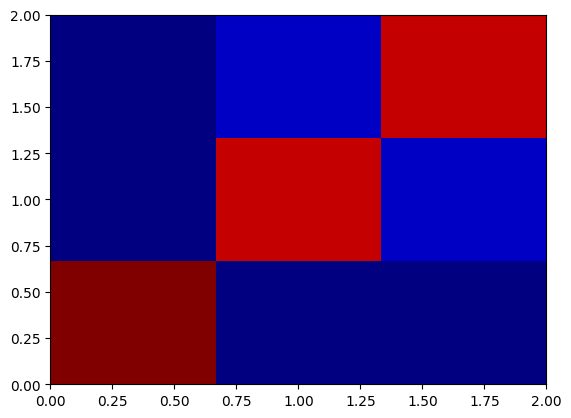

In [10]:
import matplotlib.pyplot as plt
plt.hist2d(iris.target, y_pred_all, bins=(3, 3), cmap=plt.cm.jet)
plt.show()